## Esercitazione 7 -  9 Aprile 2024

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
import IPython.display as nb
import radixmethods as meth
from displayutils import *
from sympy.utilities.lambdify import lambdify
from funcutils import FunctionApprox
from itertools import takewhile

#Costants
tolx = 1e-12
tolf = 1e-12
nmax = 1000

Scrivere la function `NewtonRaphson_corde.py`, che implementa il metodo di Newton-Raphson con la variante delle corde
per il calcolo della soluzione di un sistema di equazioni non lineari. 

``` python
    def newton_raphson_chord(f, J, X0, tolx, tolf, nmax):
        return newton_raphson(f, J, X0, tolx, tolf, nmax, s=lambda f, J, X: -np.linalg.solve(J(x0), f(X)))
```

deve assumere come dati in input:
- fname: nome della funzione vettoriale di cui calcolare lo zero;
- JacName: nome della funzione che calcola lo J acobiano della funzione vettoriale;
- X0: vettore contenente le componenti dell'iterato iniziale);
- tolx tolleranza  per il test d'arresto sull'incremento
        $\frac{||X_{k+1}-X_k||}{||X_{k}||}<= tolx$
- tolf tolleranza per il test del residuo
        $||F(X_{k+1})|| <= tolf$
- NMAX numero massimo di iterazioni.
In output devono essere restituiti il vettore contenente l'approssimazione dello zero x, un vettore contenente l'errore relativo tra due iterati successivi, il numero di iterazioni
effettuate, nit.

Scrivere la function `NewtonRaphson_sham.py`, che implementa il metodo di Newton-Raphson con la variante di Shamanskii
per il calcolo della soluzione di un sistema di equazioni non lineari. 

    Tale function
deve assumere come dati in input:
- fname: nome della funzione vettoriale di cui calcolare lo zero;
- JacName: nome della funzione che calcola lo J acobiano della funzione vettoriale;
- X0: vettore contenente le componenti dell'iterato iniziale);
- tolx tolleranza  per il test d'arresto sull'incremento
        ||X_{k+1}-X_k||/||X_{k}||<= tolx
- tolf tolleranza per il test del residuo
        ||F(Xk+1)|| <= tolf;
- NMAX numero massimo di iterazioni.
In output devono essere restituiti il vettore contenente l'approssimazione dello zero x, un vettore contenente l'errore relativo tra due iterati successivi, il numero di iterazioni
effettuate, nit.



Risolvere i seguenti tre sistemi non lineari:
1) 
$
\begin{cases}
   2x_0-\cos(x_1)=0\\
   \sin(x_0)+2x_1=0
\end{cases}
$

2) 
$
\begin{cases}
   x_0^2+x_1^2-9=0\\
   x_0+x_1-3=0
\end{cases}
$

3) 
$
\begin{cases}
   4x_0^2+x_1^2=4\\
   x_0+x_1=\sin(x_0-x_1)
\end{cases}
$


utilizzando il metodo di Newton Raphson, la variante delle corde e la variante di Shamanskii.
Confrontare per ciascun metodo il grafico dell'errore relativo tra due iterati successivi.

In [5]:
def Jacobian (funcs, var, literal=False):
    return np.array([[fun.partial_derivative(str(s))[0] if not literal else fun.partial_derivative(str(s))[1] for s in var] for fun in funcs])
        
def plot_err_relative(method):
    _, it, err = method
    plt.semilogy(np.arange(it), err, "o-")

def print_system_data(fun_symb, functions, newthon_raphson_variants, sol=False):
    funcs = [FunctionApprox(fun, symbols=fun_symb, notation=f'f_{i}') for i, fun in enumerate(functions[0])]
    
    J = lambda X: np.array([[fu(*X) for i, fu in enumerate(v)] for v in Jacobian(funcs, fun_symb)])
    f = lambda X: np.array([fun(*X) for fun in [fun.func for fun in funcs]])

    [display_function(fun.sym_expr, varsym=fun.symbols) for fun in funcs]
    if sol:
        results_normal = [meth.newton_raphson_optimized(f, J, x0, tolx, tolf, nmax) for x0 in functions[1]]
        [display_vector(z, notation=f"s_{i}") for i, (z, _, _) in enumerate(results_normal)]

        for index, met in enumerate(newthon_raphson_variants.values()):
            for _, x0 in enumerate(functions[1]):
                plot_err_relative(met(f, J, x0, tolx, tolf, nmax))
                
        plt.legend(list(newthon_raphson_variants.keys()))
        plt.show()    

In [6]:
symbs = sym.symbols('x y')
systems_eq = {
    1: ((lambda x0, x1: 2 * x0 - sym.cos(x1), lambda x0, x1: sym.sin(x0) + 2 * x1),
        [[1, 2]]),
    2: ((lambda x0, x1: x0**2 + x1**2 - 9,  lambda x0, x1: x0 + x1 - 3),
        [[4, 0]]),
    3: ((lambda x0, x1: 4 * x0**2 + x1**2 - 4, lambda x0, x1: x0 + x1 - sym.sin(x0-x1)),
      [[1, 0]])
}
newthon_raphson_variants = {"newthon-raphson": meth.newton_raphson_optimized, "chord": meth.newton_raphson_chord, 'shamanski (m=5)': meth.newton_raphson_sham}

[print_system_data(symbs, data, newthon_raphson_variants, sol=True) for i, data in systems_eq.items()]

## Esercizio 2

Scrivere la function `NewtonRaphson_minimo.py`, che implementa il metodo di Newton-Raphson con la variante delle corde
per il calcolo del minimo assoluto (relativo) di una funzione non lineare.

In [2]:
def iterate(func, start):
    while True:
        yield start
        start = func(start)

def newton_raphson_minimo(gradient, H, X0, tolx, tolf, NMAX, s):
    if np.linalg.det(H(X0)) == 0:
        print("soluzioni non calcolabili")
        return None, None, None
        
    def stop_criteria(i, X):
        return i < nmax and np.linalg.det(H(X)) != 0 and np.linalg.norm(s(gradient, H, X)) / np.linalg.norm(X) > tolx and np.linalg.norm(gradient(X)) >= tolf

    iter = iterate(lambda xk: xk + s(gradient, H, xk), X0)
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), \
                              enumerate(iter))).values()) + [next(iter)] 
        
    return arr[-1], len(arr), arr

deve assumere come dati in input:
- grad_name: nome della  funzione vettoriale  che contine il gradiente della funzione di cui calcolare lo zero;
- Hess_name: nome della funzione che calcola l' Hessiana della funzione vettoriale;
- X0: vettore contenente le componenti dell'iterato iniziale);
- tolx tolleranza  per il test d'arresto sull'incremento
        ||X_{k+1}-X_k||/||X_{k}||<= tolx
- tolf tolleranza per il test del residuo
        ||F(Xk+1)|| <= tolf;
- NMAX numero massimo di iterazioni.
In output devono essere restituiti il vettore contenente l'approssimazione dello zero x, un vettore contenente l'errore relativo tra due iterati successivi, il numero di iterazioni
effettuate, nit.

In [61]:
def print_min(function, fun_symb, x0, x):
    gradient = lambda f, var: [f.partial_derivative(str(x))[0] for x in var]
    
    def Jacobian (funcs, var, literal=False):
        return np.array([[fun.partial_derivative(str(s))[0] for s in var] for fun in funcs])
    
    def Hessian(f, var): 
        gradients = [FunctionApprox(grad, symbols=fun_symb) for grad in gradient(f, var)]
        return np.transpose(Jacobian(gradients, var))
                 
    H = lambda X: np.array([[fu(*X) for i, fu in enumerate(v)] for v in Hessian(function, fun_symb)])
    g = lambda X: np.array([grad(*X) for grad in gradient(function, fun_symb)])
    
    zero, it, _ = newton_raphson_minimo(g, H, x0, tolx, tolf, nmax, lambda f, H, X: -np.linalg.solve(H(x0), f(X)))
    #function infos and result
    display_function(function.sym_expr, varsym=fun_symb)
    print(f"\nLocal mininum Coordinates:")
    display_vector(zero, notation='m')
    print(f"\nNumber of iterations → {it}\n")
    
    #plotting tasks
    # plot_contour(x, x, function.func, 0, "")
    ax = plot_3D_projection(x, x, function.func)
    ax.scatter(zero[0], zero[1], function.func(*zero), color='k', s=50)
    plt.show()

In [62]:
fun_symb = sym.symbols('x, y')
function = FunctionApprox(lambda x0, x1: (x0)**2 + (x1)**2 -4*x0 - 2*x1, symbols=fun_symb, notation=f'f')
x0 = [-0.5, 2]
x = np.arange(-1.5, 5, 0.01)

<IPython.core.display.Latex object>


Local mininum Coordinates:


<IPython.core.display.Latex object>


Number of iterations → 2



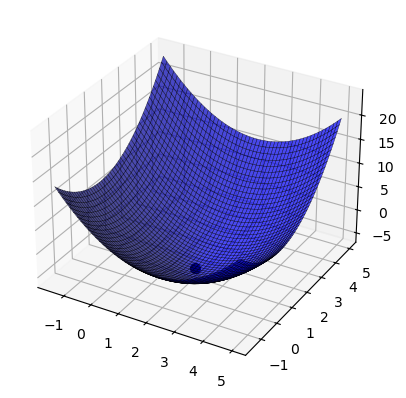

In [63]:
print_min(function, fun_symb, x0, x)

## Esercizio 3
Scrivere una funzione numpy che calcola la norma infinito e la norma 1 di un vettore ed una matrice  e testarla su vettori e matrici  a propria scelta. Confrontarne i risultati con quelli ottenuti utilizzando la funzione norm di numpy.linalg

(Ricorda la formula della norma infinito e della norma 1 di una matrice
$||A||_\infty= \max_{j=1,n} \sum_{i} |a_{ij}| $
$\quad ||A||_1= \max_{i=1,n} \sum_{j} |a_{ij}| $)

In [1]:
show_norm = lambda p, norm, comment="", mat_name="A": \
    nb.display( \
        nb.Latex( \
            f"{comment}: $||{mat_name}||_"+"{"+f"{str(p)}"+"}"+ f"={norm}$" \
        ) \
    ) 

In [2]:
norm_inf = lambda A: max(np.sum(np.abs(A), axis=1))
norm1 = lambda A: max(np.sum(np.abs(A), axis=0))

In [81]:
#input
A = np.array([[2, -3], [4, 5]])
display_matrix(A, notation='A')
#solutions
show_norm(1, norm1(A), comment="Implemented Norm 1")
show_norm("\infty", norm_inf(A), comment="Implemented Norm Infinity")
show_norm(1, np.linalg.norm(A, 1), comment="Numpy algo for Norm 1")
show_norm("\infty", np.linalg.norm(A, np.inf), comment="Numpy algo for Norm Infinity")


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## Esercizio 4
Implementare una funzione che calcola la norma 2 di una  matrice facendo uso della funzione eigvals del pacchetto numpy.linalg, (np.linalg.eigvals(A)). Testarla sulla matrice A=np.array([[4,-1,6],[2,3,-3],[1,-2,9/2]])   e confrontarne i risultati con quelli ottenuti utilizzando la funzione norm di numpy.linalg

In [106]:
norm2 = lambda A: np.sqrt(np.max(np.linalg.eigvals(np.transpose(A) @ A)))
norm2SE = lambda A: np.sqrt(np.sum(A**2))

In [109]:
#input
A = np.array([[4,-1,6],[2,3,-3],[1,-2,9/2]])
display_matrix(A, notation='A')
#solutions
show_norm(2, np.linalg.norm(A, 2), comment="Numpy algo for Norm 2")
show_norm(2, norm2(A), comment="Implemented Norm 2")
show_norm(2, norm2SE(A), comment="Implemented Norm 2 GEN/APROX")


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>